# Inspecting & Loading Data

In [706]:
import pandas as pd
import numpy as np
unfiltered_data = pd.read_pickle('DataProject.pk')
unfiltered_data
# Displaying data from pickle file

,date,asset,value,item
0,2020-01-01,ADAUSD,0.033813,daily_high
1,2020-01-01,BTCUSD,7254.330566,daily_high
2,2020-01-01,ETHUSD,132.835358,daily_high
3,2020-01-01,LINKUSD,1.851417,daily_high
4,2020-01-02,ADAUSD,0.033507,daily_high
...,...,...,...,...
3974,2020-12-30,LINK-USD,11.097195,daily_low
3975,2020-12-31,ADA-USD,0.176594,daily_low
3976,2020-12-31,BTC-USD,28201.992188,daily_low
3977,2020-12-31,ETH-USD,726.511902,daily_low


# Data Standardisation

In [707]:
unfiltered_data['asset'].unique()
# Note that there are similar tickers: For example, 'ADAUSD' and 'ADA-USD'
# Due to this error, python thinks that these two tickers are different but they are actually the same

array(['ADAUSD', 'BTCUSD', 'ETHUSD', 'LINKUSD', 'BTC-USD', 'ETH-USD',
       'LINK-USD', 'ADA-USD'], dtype=object)

In [708]:
# Ticker Analysis: 8 labels exist, but there are two label conventions for each ticker
# for example BTC-USD vs BTCUSD

In [709]:
unfiltered_data['asset'].value_counts()
# Looking at the 632 vs 633: this mean that there is a missing data point for 'ADA-USD'

asset
BTC-USD     633
ETH-USD     633
LINK-USD    633
ADA-USD     632
ADAUSD      362
BTCUSD      362
ETHUSD      362
LINKUSD     362
Name: count, dtype: int64

In [710]:
time_stamp1 = pd.to_datetime(unfiltered_data['date'])
unfiltered_data['date'] = time_stamp1
# converting the date into pandas datetime values

In [711]:
index_data = unfiltered_data.set_index('date')
# making the date be our index
index_data

,asset,value,item
date,,,
2020-01-01,ADAUSD,0.033813,daily_high
2020-01-01,BTCUSD,7254.330566,daily_high
2020-01-01,ETHUSD,132.835358,daily_high
2020-01-01,LINKUSD,1.851417,daily_high
2020-01-02,ADAUSD,0.033507,daily_high
...,...,...,...
2020-12-30,LINK-USD,11.097195,daily_low
2020-12-31,ADA-USD,0.176594,daily_low
2020-12-31,BTC-USD,28201.992188,daily_low


# Data Completeness

In [712]:
unfiltered_data.groupby('asset')['date'].nunique()
# Finds the number of unique dates for each ticker

asset
ADA-USD     362
ADAUSD      362
BTC-USD     362
BTCUSD      362
ETH-USD     362
ETHUSD      362
LINK-USD    362
LINKUSD     362
Name: date, dtype: int64

In [713]:
unfiltered_data.groupby('item')['date'].nunique()
#Finds the number of unique dates for each item

item
daily_high    362
daily_low     271
daily_ret     362
Name: date, dtype: int64

In [714]:
unfiltered_data.groupby(['asset','item'])['date'].nunique()
# Finds the number of unique dates for every combination of asset and item

asset     item      
ADA-USD   daily_low     271
          daily_ret     361
ADAUSD    daily_high    362
BTC-USD   daily_low     271
          daily_ret     362
BTCUSD    daily_high    362
ETH-USD   daily_low     271
          daily_ret     362
ETHUSD    daily_high    362
LINK-USD  daily_low     271
          daily_ret     362
LINKUSD   daily_high    362
Name: date, dtype: int64

In [715]:
calendar_dates = pd.date_range('20200101','20201231', freq = 'D')
calendar_dates
#dates in a year

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04',
               '2020-01-05', '2020-01-06', '2020-01-07', '2020-01-08',
               '2020-01-09', '2020-01-10',
               ...
               '2020-12-22', '2020-12-23', '2020-12-24', '2020-12-25',
               '2020-12-26', '2020-12-27', '2020-12-28', '2020-12-29',
               '2020-12-30', '2020-12-31'],
              dtype='datetime64[ns]', length=366, freq='D')

In [716]:
asset_item_missing_dates = unfiltered_data.groupby(['asset','item'])['date'].apply(lambda x: calendar_dates.difference(x))
asset_item_missing_dates 
# Shows the missing dates of data for every asset-item combination

asset     item      
ADA-USD   daily_low     DatetimeIndex(['2020-04-17', '2020-07-02', '20...
          daily_ret     DatetimeIndex(['2020-01-01', '2020-04-17', '20...
ADAUSD    daily_high    DatetimeIndex(['2020-04-17', '2020-10-09', '20...
BTC-USD   daily_low     DatetimeIndex(['2020-04-17', '2020-07-02', '20...
          daily_ret     DatetimeIndex(['2020-04-17', '2020-10-09', '20...
BTCUSD    daily_high    DatetimeIndex(['2020-04-17', '2020-10-09', '20...
ETH-USD   daily_low     DatetimeIndex(['2020-04-17', '2020-07-02', '20...
          daily_ret     DatetimeIndex(['2020-04-17', '2020-10-09', '20...
ETHUSD    daily_high    DatetimeIndex(['2020-04-17', '2020-10-09', '20...
LINK-USD  daily_low     DatetimeIndex(['2020-04-17', '2020-07-02', '20...
          daily_ret     DatetimeIndex(['2020-04-17', '2020-10-09', '20...
LINKUSD   daily_high    DatetimeIndex(['2020-04-17', '2020-10-09', '20...
Name: date, dtype: object

In [717]:
asset_item_missing_dates.values
# neater way of presenting missing values

array([DatetimeIndex(['2020-04-17', '2020-07-02', '2020-07-03', '2020-07-04',
                      '2020-07-05', '2020-07-06', '2020-07-07', '2020-07-08',
                      '2020-07-09', '2020-07-10', '2020-07-11', '2020-07-12',
                      '2020-07-13', '2020-07-14', '2020-07-15', '2020-07-16',
                      '2020-07-17', '2020-07-18', '2020-07-19', '2020-07-20',
                      '2020-07-21', '2020-07-22', '2020-07-23', '2020-07-24',
                      '2020-07-25', '2020-07-26', '2020-07-27', '2020-07-28',
                      '2020-07-29', '2020-07-30', '2020-07-31', '2020-08-01',
                      '2020-08-02', '2020-08-03', '2020-08-04', '2020-08-05',
                      '2020-08-06', '2020-08-07', '2020-08-08', '2020-08-09',
                      '2020-08-10', '2020-08-11', '2020-08-12', '2020-08-13',
                      '2020-08-14', '2020-08-15', '2020-08-16', '2020-08-17',
                      '2020-08-18', '2020-08-19', '2020-08-20', 

In [718]:
asset_item_missing_dates.apply(lambda x: len(x))
# mulit index series showing the number of missing dates for each asset-item combo

asset     item      
ADA-USD   daily_low     95
          daily_ret      5
ADAUSD    daily_high     4
BTC-USD   daily_low     95
          daily_ret      4
BTCUSD    daily_high     4
ETH-USD   daily_low     95
          daily_ret      4
ETHUSD    daily_high     4
LINK-USD  daily_low     95
          daily_ret      4
LINKUSD   daily_high     4
Name: date, dtype: int64

In [719]:
# Missing Date Analysis: The data set contains systematic missing dates. daily_low for each assset has 95 missing dates.
# While each daily_ret and daily_high has 4 missing dates with the execption of ADA-USD daily_ret that has 5 missing dates.

In [720]:
asset_item_date = unfiltered_data.groupby(['asset','item','date'])['date'].count()
asset_item_date

asset    item        date      
ADA-USD  daily_low   2020-01-01    1
                     2020-01-02    1
                     2020-01-03    1
                     2020-01-04    1
                     2020-01-05    1
                                  ..
LINKUSD  daily_high  2020-12-27    1
                     2020-12-28    1
                     2020-12-29    1
                     2020-12-30    1
                     2020-12-31    1
Name: date, Length: 3979, dtype: int64

In [721]:
asset_item_date.loc[(asset_item_date > 1)]
# showing data that value > 1. so showing data that has duplicates

Series([], Name: date, dtype: int64)

In [722]:
# Duplicate Data Analysis: Since the series above is empty, there are no duplicates

# Statistical Analysis & Outlier Detection 

In [723]:
daily_low_summary = index_data.loc[index_data['item'] == 'daily_low']
daily_low_summary.describe()
#Statistical Summary of daily_low

,value
count,1084.000000
mean,2793.362047
std,5293.690393
min,0.019130
25%,0.758031
50%,3.794358
75%,1571.629166
max,28201.992188


In [724]:
daily_low_summary.groupby('asset').describe()
#ETH-USD looks suspicious by the sudden jump from the median to the 75th percentile

value                                                       \
          count          mean          std          min          25%   
asset                                                                  
ADA-USD   271.0      0.073226     0.039605     0.019130     0.042232   
BTC-USD   271.0  10982.624732  4751.865495  4106.980957  8310.858398   
ETH-USD   271.0    184.754110   227.522378     0.951843     1.721006   
LINK-USD  271.0      5.996121     4.040619     1.506868     3.054004   

                                                   
                  50%           75%           max  
asset                                              
ADA-USD      0.057607      0.099543      0.176594  
BTC-USD   9300.430664  12854.064941  28201.992188  
ETH-USD      2.300528    379.422623    726.511902  
LINK-USD     3.926330     10.546959     15.005792

<Axes: title={'center': 'daily low values of ADA-USD'}, xlabel='date'>

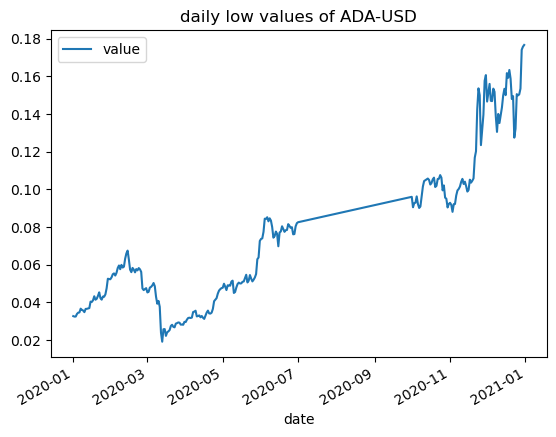

In [725]:
daily_low_summary.loc[daily_low_summary['asset'] == 'ADA-USD'].plot(title = 'daily low values of ADA-USD')
# ADA-USD shows no outliers/errors
# straight line due to the missing data from 2020-07-02 to 2020-09-30

<Axes: title={'center': 'daily low values of BTC-USD'}, xlabel='date'>

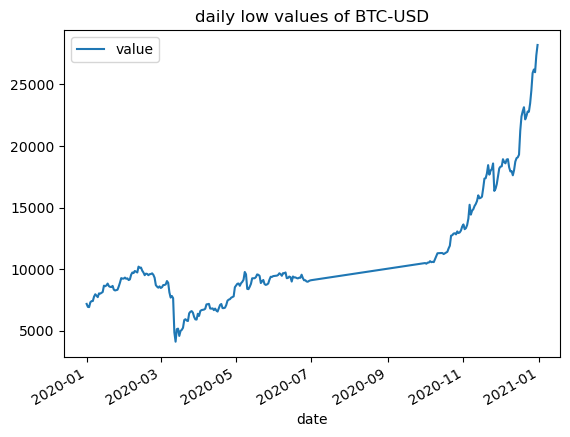

In [726]:
daily_low_summary.loc[daily_low_summary['asset'] == 'BTC-USD'].plot(title = 'daily low values of BTC-USD')
# BTC-USD shows no outliers/errors
# straight line due to the missing data from 2020-07-02 to 2020-09-30

<Axes: title={'center': 'daily low values of ETH-USD'}, xlabel='date'>

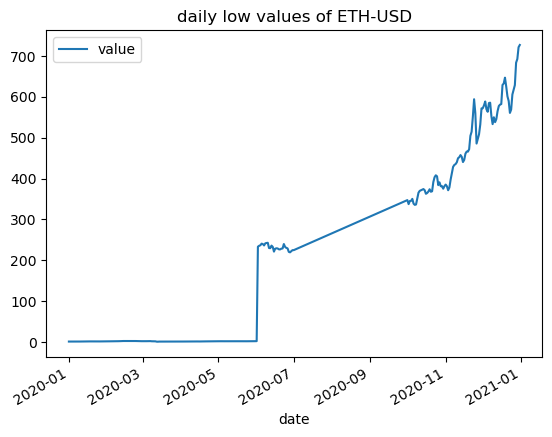

In [727]:
daily_low_summary.loc[daily_low_summary['asset'] == 'ETH-USD'].plot(title = 'daily low values of ETH-USD')
# ADA-USD has an error as there is a sudden spike around June
# straight line due to the missing data from 2020-07-02 to 2020-09-30

<Axes: title={'center': 'daily low values of LINK-USD'}, xlabel='date'>

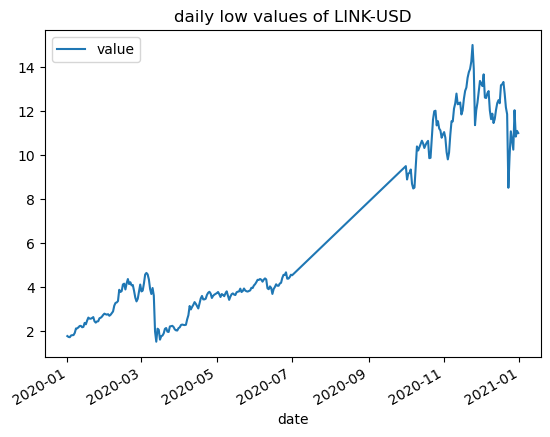

In [728]:
daily_low_summary.loc[daily_low_summary['asset'] == 'LINK-USD'].plot(title = 'daily low values of LINK-USD')
# LINK-USD shows no outliers/errors
# straight line due to the missing data from 2020-07-02 to 2020-09-30

In [729]:
daily_low_summary.loc[daily_low_summary['asset'] == 'ETH-USD']['20200525':'20200605']
# All values from 2020-01-01 to 2020-06-01 have been divided by 100

,asset,value,item
date,,,
2020-05-25,ETH-USD,2.006676,daily_low
2020-05-26,ETH-USD,2.002643,daily_low
2020-05-27,ETH-USD,2.017851,daily_low
2020-05-28,ETH-USD,2.062427,daily_low
2020-05-29,ETH-USD,2.182381,daily_low
2020-05-30,ETH-USD,2.187445,daily_low
2020-05-31,ETH-USD,2.300528,daily_low
2020-06-01,ETH-USD,2.304881,daily_low
2020-06-02,ETH-USD,233.225296,daily_low


In [730]:
daily_high_summary = index_data.loc[index_data['item'] == 'daily_high']
daily_high_summary.describe()
#Statistical Summary of daily_high

,value
count,1448.000000
mean,2907.325973
std,5327.631684
min,0.025993
25%,1.411704
50%,67.936722
75%,1274.888672
max,29244.876953


In [731]:
daily_high_summary.groupby('asset').describe()
#ETH-USD looks suspicious again by the sudden jumps in the median to the 75% percentile to the max

value                                                       \
         count          mean          std          min          25%   
asset                                                                 
ADAUSD   362.0      0.089687     0.043156     0.025993     0.051493   
BTCUSD   362.0  11306.644431  4399.843207  2836.645020  9037.108887   
ETHUSD   362.0    314.841528   148.013107   116.021622   205.904774   
LINKUSD  362.0      7.728245     4.783576     1.816882     3.825582   

                                                  
                 50%           75%           max  
asset                                             
ADAUSD      0.087889      0.124195      0.196170  
BTCUSD   9836.208496  11799.821533  29244.876953  
ETHUSD    248.325653    399.151688    754.303223  
LINKUSD     4.896292     12.326414     19.851822

<Axes: title={'center': 'daily high of ADA-USD'}, xlabel='date'>

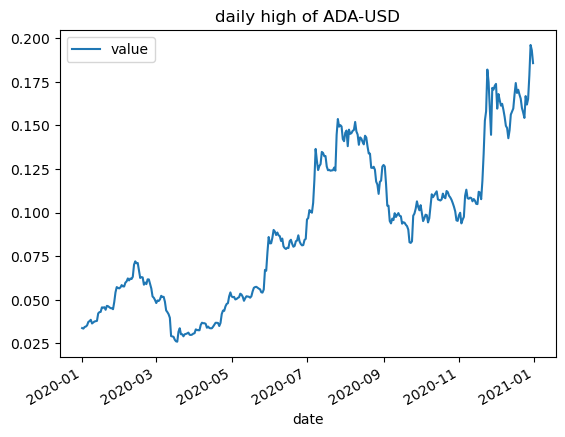

In [732]:
daily_high_summary.loc[daily_high_summary['asset'] == 'ADAUSD'].plot( title = 'daily high of ADA-USD')
# ADA-USD shows no outliers/errors

<Axes: title={'center': 'daily high of BTC-USD'}, xlabel='date'>

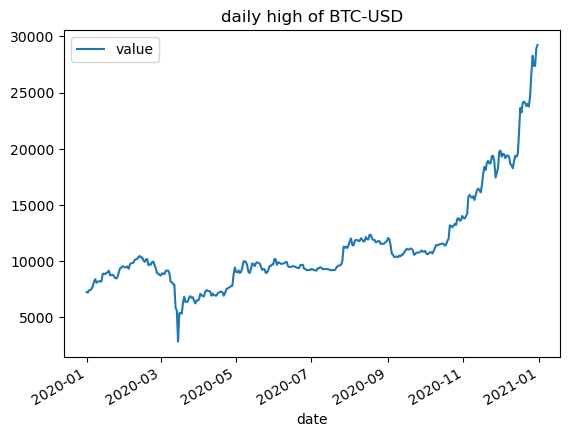

In [733]:
daily_high_summary.loc[daily_high_summary['asset'] == 'BTCUSD'].plot( title = 'daily high of BTC-USD')
# BTC-USD shows no outliers/errors

<Axes: title={'center': 'daily high of ETH-USD'}, xlabel='date'>

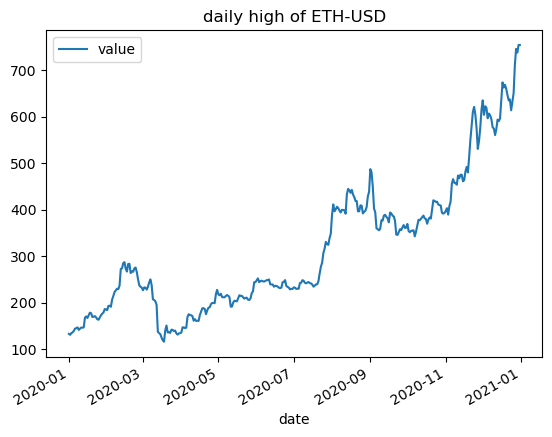

In [734]:
daily_high_summary.loc[daily_high_summary['asset'] == 'ETHUSD'].plot( title = 'daily high of ETH-USD')
# ETH-USD shows no outliers/errors

<Axes: title={'center': 'daily high of LINK-USD'}, xlabel='date'>

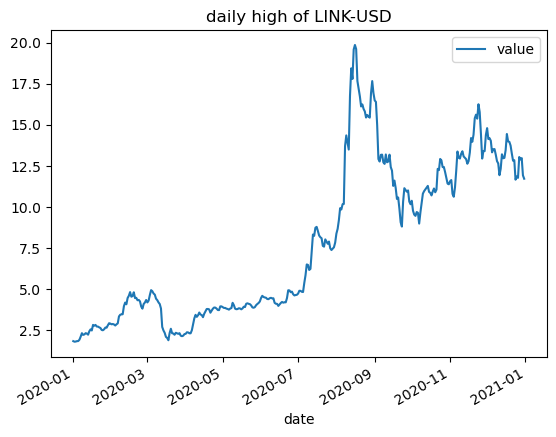

In [735]:
daily_high_summary.loc[daily_high_summary['asset'] == 'LINKUSD'].plot( title = 'daily high of LINK-USD')
# LINK-USD shows no outliers/errors

In [736]:
daily_ret_summary = index_data.loc[index_data['item'] == 'daily_ret']
daily_ret_summary.describe()
#Statistical Summary of daily_ret

,value
count,1447.000000
mean,-147.049115
std,354.076337
min,-999.000000
25%,-0.041656
50%,-0.002401
75%,0.022901
max,0.279402


In [737]:
daily_ret_summary.groupby('asset').describe()
# BTC, ETH & LINK are all suspicious as all minimum data is -999 whihc is very likely an error

value                                                            \
          count        mean         std         min         25%       50%   
asset                                                                       
ADA-USD   361.0    0.006433    0.058148   -0.395672   -0.022893  0.004557   
BTC-USD   362.0  -85.545851  279.933124 -999.000000   -0.015206  0.001046   
ETH-USD   362.0 -168.335241  374.462337 -999.000000   -0.041088 -0.003846   
LINK-USD  362.0 -333.915569  471.912665 -999.000000 -999.000000 -0.028047   

                              
               75%       max  
asset                         
ADA-USD   0.034885  0.201887  
BTC-USD   0.015859  0.181878  
ETH-USD   0.022562  0.189404  
LINK-USD  0.019937  0.279402

<Axes: title={'center': 'daily ret of ASA-USD'}, xlabel='date'>

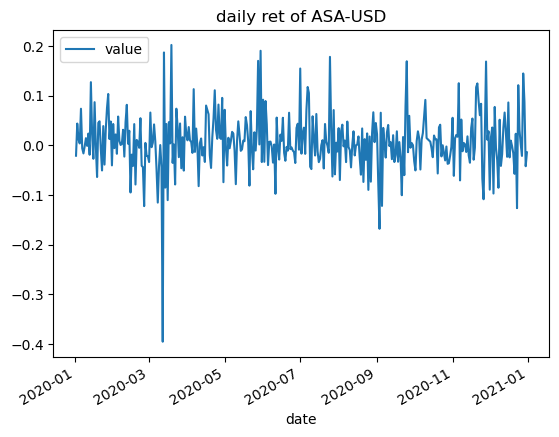

In [738]:
daily_ret_summary.loc[daily_ret_summary['asset'] == 'ADA-USD'].plot(title = 'daily ret of ASA-USD')

<Axes: title={'center': 'daily ret of BTC-USD'}, xlabel='date'>

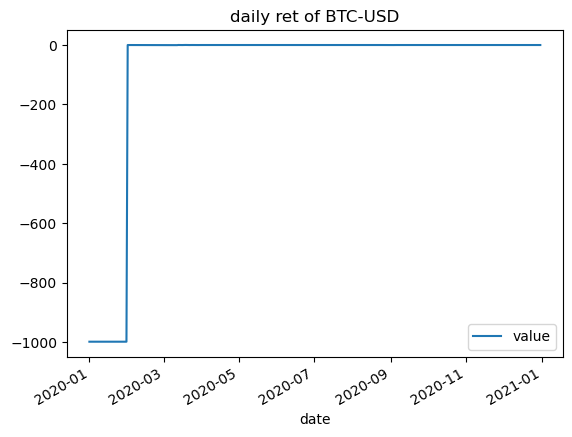

In [739]:
daily_ret_summary.loc[daily_ret_summary['asset'] == 'BTC-USD'].plot(title = 'daily ret of BTC-USD')
# from the sudden spike this is definitely an error

<Axes: title={'center': 'daily ret of ETH-USD'}, xlabel='date'>

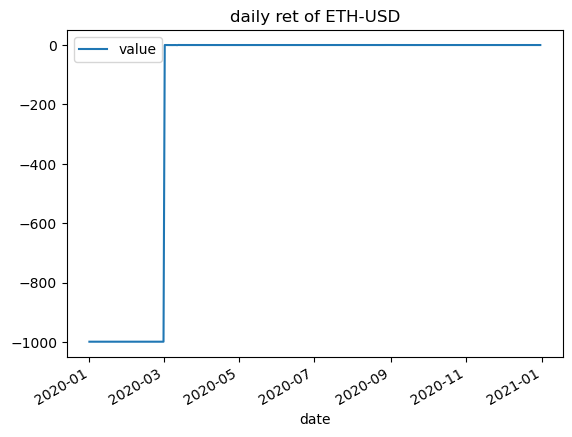

In [740]:
daily_ret_summary.loc[daily_ret_summary['asset'] == 'ETH-USD'].plot(title = 'daily ret of ETH-USD')
# from the sudden spike this is definitely an error

<Axes: title={'center': 'daily ret of LINK-USD'}, xlabel='date'>

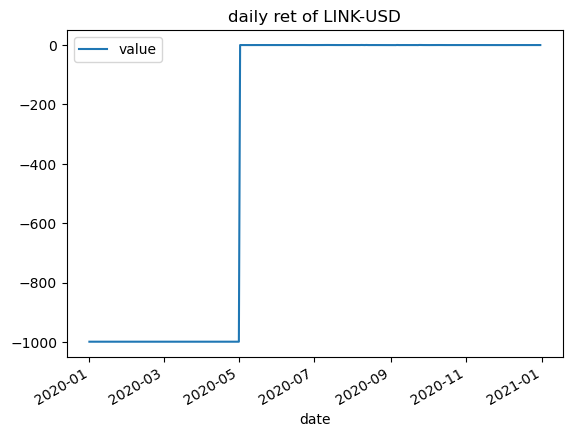

In [741]:
daily_ret_summary.loc[daily_ret_summary['asset'] == 'LINK-USD'].plot(title = 'daily ret of LINK-USD')
# from the sudden spike this is definitely an error

In [742]:
daily_ret_summary.loc[daily_ret_summary['value'] == -999, 'value'] = np.nan
daily_ret_summary.loc[daily_ret_summary['value'] == -999]
# removing all data values of -999

,asset,value,item
date,,,


<Axes: title={'center': 'daily ret of BTC-USD'}, xlabel='date'>

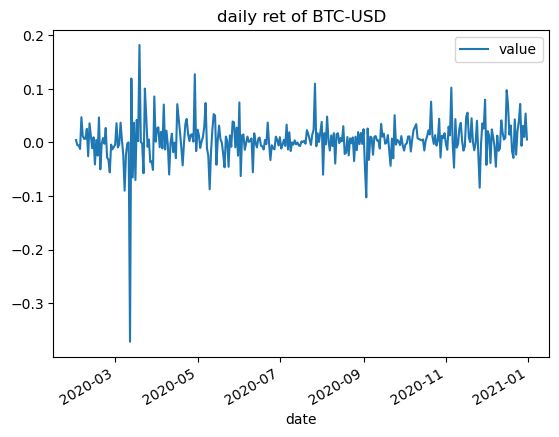

In [743]:
daily_ret_summary.loc[daily_ret_summary['asset'] == 'BTC-USD'].plot(title = 'daily ret of BTC-USD')
# BTC-USD has been fixed

<Axes: title={'center': 'daily ret of ETH-USD'}, xlabel='date'>

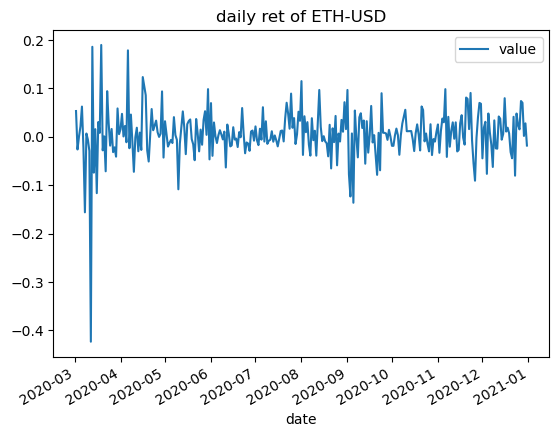

In [744]:
daily_ret_summary.loc[daily_ret_summary['asset'] == 'ETH-USD'].plot(title = 'daily ret of ETH-USD')
#ETH-USD has been fixed

<Axes: title={'center': 'daily ret of LINK-USD'}, xlabel='date'>

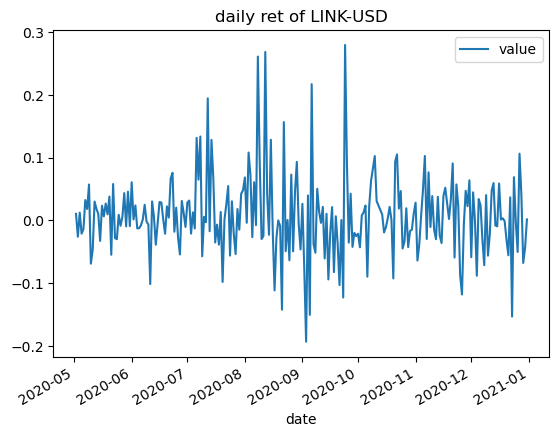

In [745]:
daily_ret_summary.loc[daily_ret_summary['asset'] == 'LINK-USD'].plot(title = 'daily ret of LINK-USD')
# LINK-USD has been fixed

In [746]:
clean_data = unfiltered_data.copy()
clean_data['asset'] = clean_data['asset'].map(lambda x: x.replace('-USD','').replace('USD',''))
clean_data.loc[clean_data['value'] == -999, 'value'] = np.nan
# Fixing asset labelling error
# Removing -999 values 

# Consistency Checks

In [747]:
comparison1 = clean_data.loc[clean_data['item'] == 'daily_high'].merge(clean_data.loc[clean_data['item'] == 'daily_low'], left_on = ['date','asset'], right_on = ['date','asset'])
comparison1
# Merging daily_low and daily_high

,date,asset,value_x,item_x,value_y,item_y
0,2020-01-01,ADA,0.033813,daily_high,0.032704,daily_low
1,2020-01-01,BTC,7254.330566,daily_high,7174.944336,daily_low
2,2020-01-01,ETH,132.835358,daily_high,1.291983,daily_low
3,2020-01-01,LINK,1.851417,daily_high,1.763420,daily_low
4,2020-01-02,ADA,0.033507,daily_high,0.032448,daily_low
...,...,...,...,...,...,...
1079,2020-12-30,LINK,11.926013,daily_high,11.097195,daily_low
1080,2020-12-31,ADA,0.185749,daily_high,0.176594,daily_low
1081,2020-12-31,BTC,29244.876953,daily_high,28201.992188,daily_low
1082,2020-12-31,ETH,754.299438,daily_high,726.511902,daily_low


In [748]:
T_F = comparison1['value_x'] > comparison['value_y']
T_F.loc[T_F.values == False]
# finding which row has a daily_low greater than a daily_high

297    False
dtype: bool

In [749]:
comparison1[297:298]
# Identifying the date of the error 
# The daily_low looks normal as they fit the data pattern
# The daily_high is the error as its much lower compared to its neighbouring data

,date,asset,value_x,item_x,value_y,item_y
297,2020-03-15,BTC,2836.64502,daily_high,5169.283203,daily_low


In [750]:
clean_data.loc[(clean_data['date'] == '2020-03-15') & (clean_data['asset'] == 'BTC') & (clean_data['item'] == 'daily_high'), 'value'] = np.nan
clean_data.loc[(clean_data['date'] == '2020-03-15') & (clean_data['asset'] == 'BTC')]
# removing the daily_high error for BTC

,date,asset,value,item
297,2020-03-15,BTC,NaN,daily_high
1744,2020-03-15,BTC,0.036911,daily_ret
3192,2020-03-15,BTC,5169.283203,daily_low


In [751]:
comparison2 = clean_data.loc[clean_data['item'] == 'daily_high'].merge(clean_data.loc[clean_data['item'] == 'daily_low'], left_on = ['date','asset'], right_on = ['date','asset'])
comparison2[297:298]
# sanity check to ensure '2020-03-15' daily_high is NaN

,date,asset,value_x,item_x,value_y,item_y
297,2020-03-15,BTC,NaN,daily_high,5169.283203,daily_low


In [752]:
time_stamp2 = pd.to_datetime(clean_data['date'])
clean_data['date'] = time_stamp2
clean_data = clean_data.set_index('date')

In [753]:
clean_data.loc[(clean_data['asset'] == 'ETH') & (clean_data['item'] == 'daily_low') & (clean_data.index <= '2020-06-01'),'value' ] = clean_data.loc[(clean_data['asset'] == 'ETH') & (clean_data['item'] == 'daily_low') & (clean_data.index <= '2020-06-01'),'value'] *100
# multiplpying the erraneous of ETH daily_lows by 100 

In [754]:
clean_data.loc[(clean_data['asset'] == 'ETH') & (clean_data['item'] == 'daily_low') & (clean_data.index <= '2020-06-01')]
# checking that values have been multiplied for 100

,asset,value,item
date,,,
2020-01-01,ETH,129.198288,daily_low
2020-01-02,ETH,126.954910,daily_low
2020-01-03,ETH,126.490021,daily_low
2020-01-04,ETH,133.040558,daily_low
2020-01-05,ETH,135.045624,daily_low
...,...,...,...
2020-05-28,ETH,206.242661,daily_low
2020-05-29,ETH,218.238052,daily_low
2020-05-30,ETH,218.744461,daily_low


In [755]:
check_data = clean_data.pivot_table(index = clean_data.index, columns = ['asset','item'], values = 'value')
# formatting data to calculate max/min ret 

In [756]:
max_ret = check_data.xs('daily_high', level='item', axis=1) / check_data.xs('daily_low', level='item', axis=1).shift() - 1
min_ret = check_data.xs('daily_low', level='item', axis=1) / check_data.xs('daily_high', level='item', axis=1).shift() - 1
actual_ret = check_data.xs('daily_ret', level='item', axis=1)
# setting up the maximum and minimum possible daily return
max_break = actual_ret > max_ret
min_break = actual_ret < min_ret
# Comparing the actual returns with the max/min returns to ensure no inconsistencies
print(max_break.sum())
min_break.sum()
# There are no daily rets outside the bounds so this completes our final check

asset
ADA     0
BTC     0
ETH     0
LINK    0
dtype: int64


asset
ADA     0
BTC     0
ETH     0
LINK    0
dtype: int64

# Final Conclusions

Key findings

The dataset contained several data-quality issues that were identified through statistical analysis, visualisation and consistency checks:

* Inconsistent asset labels: The same cryptocurrencies were represented using two different ticker conventions, such as BTCUSD and BTC-USD. These were standardised.
* Missing observations: Several dates were missing for certain asset/item combinations, including a large period of missing daily_low data.
* Invalid daily returns: A value of -999 appeared in daily_ret and was identified as an invalid placeholder. These values were replaced with NaN.
* ETH daily-low error: ETH daily_low values before 2 June 2020 were approximately 100 times too small. These values were corrected by multiplying them by 100.
* BTC daily-high error: On 15 March 2020, the BTC daily_high was lower than its daily_low, which is impossible. The erroneous high value was replaced with NaN.

Verification

After correcting the identified errors, additional consistency checks were performed:

* No duplicate (date, asset, item) observations were found.
* No remaining cases violated daily_high ≥ daily_low, excluding intentionally missing values.
* No daily returns exceeded the mathematically possible bounds implied by the daily high and low prices.

Overall conclusion

The dataset contained several inconsistencies and erroneous observations, but these were identified and corrected using a combination of exploratory analysis, statistical summaries, visualisation and logical consistency checks. The final dataset is cleaner and more suitable for further analysis.